### Chapter 3: Coding Attention Mechanisms
### 3.3 Attending to different parts of the input with self-attention
### 3.3.1 A simple self-attention mechanism without trainable weights

In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [ ]:
input_query = inputs[1]
input_query

tensor([0.5500, 0.8700, 0.6600])

In [ ]:
input_1 = inputs[0]
input_1

tensor([0.4300, 0.1500, 0.8900])

In [ ]:
torch.dot(input_query, input_1)

tensor(0.9544)

### Now let's do this for all of them all at once


#### In normal python u can have a list , have a res variable and append your result to it, but in pytorch u have vectors and tensors which are of fixed size, you can theoritically extend them but it is not efficient to do so

In [ ]:
query = inputs[1]

# attention scores of input query which is x2 , so we calc w21,w22,w23,w24,w25,w26
attn_scores_2 = torch.empty(inputs.shape[0]) 
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [ ]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
attn_weights_2_tmp

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])

In [ ]:
attn_weights_2_tmp.sum()

tensor(1.0000)

In [ ]:
def softmax_naive(x):
     return torch.exp(x) / torch.exp(x).sum(dim = 0)

softmax_naive(attn_scores_2)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

#### you might think both of these softmax functions give the same values but there will be some values where the naive method will be unstable

In [ ]:
attn_weights_2 = torch.softmax(attn_scores_2, dim = 0)

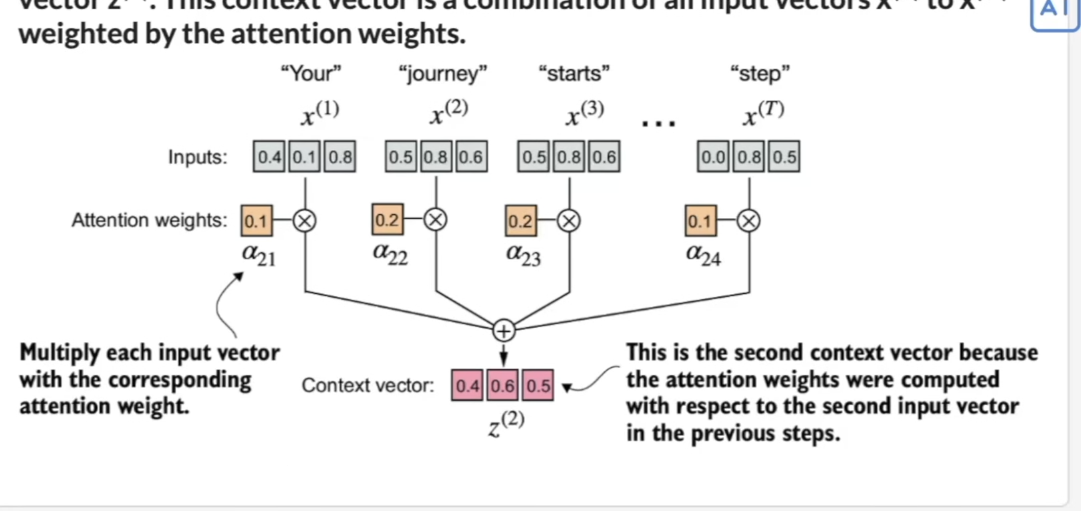

Let's compute context vector now which is a weighted sum of attention weights and inputs

In [ ]:
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
    print(f"{attn_weights_2[i]} ----> {inputs[i]}")
    context_vec_2 += attn_weights_2[i] * inputs[i]

print(context_vec_2)

0.13854756951332092 ----> tensor([0.4300, 0.1500, 0.8900])
0.2378913015127182 ----> tensor([0.5500, 0.8700, 0.6600])
0.23327402770519257 ----> tensor([0.5700, 0.8500, 0.6400])
0.12399158626794815 ----> tensor([0.2200, 0.5800, 0.3300])
0.10818186402320862 ----> tensor([0.7700, 0.2500, 0.1000])
0.15811361372470856 ----> tensor([0.0500, 0.8000, 0.5500])
tensor([0.4419, 0.6515, 0.5683])


### 3.3.2 A simple self-attention mechanism without trainable weights

In [ ]:

attn_scores = torch.empty(6,6) 

for i, x_i in enumerate(inputs):
    for j , x_j in enumerate(inputs):
        attn_scores[i,j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


### Can do it much easier using matmul

In [ ]:
attn_scores = inputs @ inputs.T
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In [ ]:
attn_weights = torch.softmax(attn_scores, dim = 1)

In [ ]:
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

In [ ]:
attn_weights.sum(dim = -1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [ ]:
attn_scores = inputs @ inputs.T
attn_weights = torch.softmax(attn_scores, dim = 1)
print(attn_weights)
all_context_vecs = attn_weights @ inputs
all_context_vecs

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

### 3.4 Implementing self-attention with trainable weights

### 3.4.1 Computing the attention weights step by step

In [ ]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2
print(x_2)
d_in

tensor([0.5500, 0.8700, 0.6600])


3

In [ ]:
torch.manual_seed(123)
w_query = torch.nn.Parameter(torch.rand(d_in, d_out)) # this torch.nn.paramter allows the weights to be trainable
w_key = torch.nn.Parameter(torch.rand(d_in, d_out))
w_value = torch.nn.Parameter(torch.rand(d_in, d_out))
print(w_query)
print(w_key)
print(w_value)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]], requires_grad=True)
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]], requires_grad=True)
Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]], requires_grad=True)


In [ ]:
query_2 = x_2 @ w_query
query_2

tensor([0.4306, 1.4551], grad_fn=<SqueezeBackward4>)

In [ ]:
keys = inputs @ w_key
values = inputs @ w_value

keys.shape

torch.Size([6, 2])

In [ ]:
keys

tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]], grad_fn=<MmBackward0>)

In [ ]:
keys_2 = keys[1]
attn_score_22 = torch.dot(query_2, keys_2)

In [ ]:
attn_score_22

tensor(1.8524, grad_fn=<DotBackward0>)

In [ ]:
attn_scores_2 = query_2 @ keys.T
attn_scores_2

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
       grad_fn=<SqueezeBackward4>)

In [ ]:
d_k = keys.shape[1]

# why do like this?, this is how its done within the attention is all u need paper, the normalization with sqrt of dimension part
attn_weights_2 = torch.softmax(attn_scores_2/ d_k**0.5, dim = -1)
attn_weights_2

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
       grad_fn=<SoftmaxBackward0>)

In [ ]:
attn_weights_2.sum()

tensor(1.0000, grad_fn=<SumBackward0>)

In [ ]:
context_vec_2 = attn_weights_2 @ values
context_vec_2

tensor([0.3061, 0.8210], grad_fn=<SqueezeBackward4>)

In [ ]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.w_query = torch.nn.Parameter(torch.rand(d_in, d_out))
        self.w_key = torch.nn.Parameter(torch.rand(d_in, d_out))
        self.w_value = torch.nn.Parameter(torch.rand(d_in, d_out))
    
    def forward(self, x):
        queries = inputs @ w_query
        keys = inputs @ w_key
        values = inputs @ w_value

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / d_k ** 0.5 , dim = -1)
        context_vec = attn_weights @ values

        return context_vec

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
sa_v1(inputs)


tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

In [ ]:
inputs
# so each tensor row above is the context vector corresponding to this as a query

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

## We can optimize the above class using linear layers which are more efficient than torch.rand

In [ ]:
m = torch.nn.Linear(2,3)
m.weight

Parameter containing:
tensor([[ 0.5053,  0.5647],
        [-0.6519,  0.6036],
        [ 0.3377,  0.3081]], requires_grad=True)

The Linear method in torch takes into account the dimensions while doing weight initialization so it takes into it leads to better training dynamics

In [ ]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias = False):
        super().__init__()
        self.w_query = torch.nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_key =  torch.nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_value =  torch.nn.Linear(d_in, d_out, bias = qkv_bias)
    
    def forward(self, x):
        queries = self.w_query(x)
        keys = self.w_key(x)
        values = self.w_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / d_k ** 0.5 , dim = -1)
        context_vec = attn_weights @ values

        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
sa_v2(inputs)


tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)

## 3.5 Hiding future words with causal attention

### 3.5.1 Applying a causal attention mask

 ### Basically we want the LLM to see only the next token not all tokens, so we are going to mask out all the upper triangle in a square matrix
 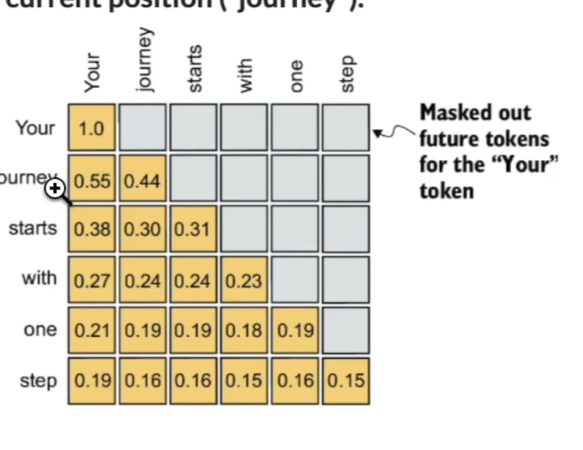

In [ ]:
queries = sa_v2.w_query(inputs)
keys = sa_v2.w_key(inputs)
values = sa_v2.w_value(inputs)

attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / d_k ** 0.5 , dim = -1)

In [ ]:
attn_weights

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

In [ ]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [ ]:
masked_simple = attn_weights * mask_simple
masked_simple

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)

In [ ]:
# normalize it now
row_sums = masked_simple.sum(dim = -1, keepdim= True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [ ]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal= 1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [ ]:
attn_weights = torch.softmax(masked / d_k ** 0.5 , dim = -1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


## But is this optimization needed?, does it give any performance improvement for anything done in production?

## Dropout mask in Attention 


#### dropout is widely used in deep learning to prevent overfitting , So the same is done in this case as well. The original GPT-2 paper has published this with the dropout mechanism, and it's like masking additional weights with dropout, but it's not being used in any modern LLMs, so it's just for educational purposes. It's good to know as well and also 

#### Also, in PyTorch, dropout is not really deterministic, so the outputs might vary. Yeah.

In [ ]:
torch.manual_seed(123)
layer = torch.nn.Dropout(0.5)

In [ ]:
example = torch.ones(6,6)
example

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

In [ ]:
layer(example)

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])

In [ ]:
dropout_rate = 0.5
1 / (1 - dropout_rate)

2.0

In [ ]:
layer(attn_weights)

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.4925, 0.4638, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3941, 0.0000],
        [0.3869, 0.3327, 0.0000, 0.3084, 0.3331, 0.3058]],
       grad_fn=<MulBackward0>)

### 3.5.3 Implementing a compact causal self attention class

In [ ]:
batch = torch.stack((inputs, inputs), dim = 0)
batch.shape

torch.Size([2, 6, 3])

what is batch concept?, what is torch.stack ? and is it the right way a batch is calculated always?

In [ ]:
import torch.nn as nn

class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out,context_length, dropout,qkv_bias = False):
        super().__init__()
        self.w_query = torch.nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_key =  torch.nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_value =  torch.nn.Linear(d_in, d_out, bias = qkv_bias)
        self.dropout = torch.nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)) 
        # So everything apart from this mask or arbitrary tensors like this are needed in training hence all other go to training but not this
    

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.w_query(x)
        keys = self.w_key(x)
        values = self.w_value(x)

        attn_scores = queries @ keys.transpose(1,2) # changed transpose why?
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], - torch.inf
        )
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim = -1
        )
        context_vec = attn_weights @ values

        return context_vec

torch.manual_seed(789)

context_length = batch.shape[1]
dropout = 0.0
ca = CausalAttention(d_in, d_out, context_length, dropout)
ca(batch)




tensor([[[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]],

        [[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]]], grad_fn=<UnsafeViewBackward0>)

### 3.6 Extending single-head attention to multi-head attention
### 3.6.1 Stacking multiple single-head attention layers

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self,d_in, d_out, context_length, dropout, qkv_bias= False, num_heads = 2):
        super().__init__() # we are inheriting features from torch's module class
        self.heads = nn.ModuleList([
            CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) for _ in range(num_heads)
            ]) # moduleList has all of these properties with buffers and all of the other things as well

    def forward(self, x):
        # so u basically concatenate the context vectors of two heads 
        # c1, c2, c3, c4 -> (c1,c2) they correspond to first context vector, (c3,c4) they correspond to the second
        return torch.cat([head(x) for head in self.heads], dim = -1) # but this is slow, for loops are slow , they don't utlize parallelism, one for loop
    # needs to wait for other for loop

torch.manual_seed(123)

context_length = batch.shape[1]
d_in, d_out = batch.shape[-1], 2

mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout = 0.0, num_heads = 2)
mha(batch)


tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)

### 3.6.2 MHA with weight splits

- While the above is an intuitive and fully functional implementation of multi-head attention (wrapping the single-head attention `CausalAttention` implementation from earlier), we can write a stand-alone class called `MultiHeadAttention` to achieve the same

- We don't concatenate single attention heads for this stand-alone `MultiHeadAttention` class
- Instead, we create single W_query, W_key, and W_value weight matrices and then split those into individual matrices for each attention head:

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in, d_out, context_length, dropout, num_heads, qkv_bias= False):
        super().__init__()
        assert(d_out % num_heads == 0) # d_out must be divisible by num_heads

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.w_query = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_key = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_value = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.w_key(x)
        queries = self.w_query(x)
        values = self.w_value(x)


        # unroll the last dimension d_out -> num_heads * head_dim
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # transpose (1,2) (each row is token) -> (each head has token * dim)
        keys = keys.transpose(1,2)
        values = values.transpose(1,2)
        queries = queries.transpose(1,2)

        attn_scores = queries @ keys.transpose(2,3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_weights = torch.softmax(attn_scores/ keys.shape[-1]**0.5, dim = -1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1,2)


        # combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)


        return context_vec

torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2

mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.2595, 0.4014],
         [0.2583, 0.4014],
         [0.2583, 0.4014],
         [0.2575, 0.4031],
         [0.2582, 0.4026],
         [0.2575, 0.4028]],

        [[0.2595, 0.4014],
         [0.2583, 0.4014],
         [0.2583, 0.4014],
         [0.2575, 0.4031],
         [0.2582, 0.4026],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])
